In [3]:
import pandas as pd
import joblib
import json
import xgboost as xgb

print("=== 1. Cargando Datos y Configuraciones ===")

# Recuperamos los DataFrames segmentados y procesados
X_train = pd.read_pickle('data_processed/X_train.pkl')
X_test  = pd.read_pickle('data_processed/X_test.pkl')
y_train = pd.read_pickle('data_processed/y_train.pkl')
y_test  = pd.read_pickle('data_processed/y_test.pkl')
X_train_st = pd.read_pickle('data_processed/X_train_st.pkl')
y_train_st = pd.read_pickle('data_processed/y_train_st.pkl')

# Recuperamos el escalador 
scaler = joblib.load('data_processed/robust_scaler.pkl')

# Extraemos el peso desde el archivo JSON
with open('data_processed/config_pesos_xgboost.json', 'r') as archivo:
    config = json.load(archivo)

xgboost_weights = config["scale_pos_weight"]

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Fraudes en y_train: {y_train.sum()}")
print(f"Tamaño de X_train_smotetomek: {X_train_st.shape}")
print(f"Fraudes en y_train_smotetomek: {y_train_st.sum()}")
print(f"-> Peso matemático recuperado: {xgboost_weights:.2f}")

=== 1. Cargando Datos y Configuraciones ===
Tamaño de X_train: (227845, 30)
Fraudes en y_train: 394
Tamaño de X_train_smotetomek: (250196, 30)
Fraudes en y_train_smotetomek: 22745
-> Peso matemático recuperado: 577.29


In [4]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
RANDOM_STATE = 42
# Espacio de búsqueda — cada parámetro tiene su lógica:
param_dist = {
    'n_estimators':    [200, 400, 600, 800],    # más árboles = más capacidad, pero más lento
    'max_depth':       [3, 4, 5, 6, 7],         # profundidad: controla complejidad del árbol
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],  # step size: lr bajo + más árboles suele ganar
    'subsample':       [0.6, 0.7, 0.8, 0.9],    # fracción de filas por árbol (reduce overfitting)
    'colsample_bytree':[0.6, 0.7, 0.8, 0.9],    # fracción de features por árbol (como RF)
    'min_child_weight':[1, 3, 5, 7],             # mínimo de muestras en hoja (regularización)
    'gamma':           [0, 0.1, 0.3, 0.5],       # ganancia mínima para split (regularización)
    'reg_alpha':       [0, 0.01, 0.1, 1],        # L1 regularization
    'reg_lambda':      [1, 1.5, 2, 5],           # L2 regularization
}

xgb_search = xgb.XGBClassifier(
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=xgboost_weights

)

# StratifiedKFold: mantiene proporción de clases en cada fold
# Usamos 5 folds — buen balance entre varianza y costo computacional
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=xgb_search,
    param_distributions=param_dist,
    n_iter=50,                    # 50 combinaciones aleatorias
    scoring='average_precision',  # AUPRC como scoring de CV
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Iniciando búsqueda de hiperparámetros")
search.fit(X_train, y_train)

print(f"\nMejores hiperparámetros encontrados:")
for param, val in search.best_params_.items():
    print(f"  {param}: {val}")
print(f"\nMejor AUPRC en CV: {search.best_score_:.4f}")

Iniciando búsqueda de hiperparámetros
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Mejores hiperparámetros encontrados:
  subsample: 0.8
  reg_lambda: 1.5
  reg_alpha: 0.1
  n_estimators: 400
  min_child_weight: 1
  max_depth: 7
  learning_rate: 0.2
  gamma: 0.1
  colsample_bytree: 0.7

Mejor AUPRC en CV: 0.8572


In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, classification_report, 
                             PrecisionRecallDisplay, ConfusionMatrixDisplay)

print("=== RESULTADOS FINALES: XGBOOST OPTIMIZADO ===")

# 1. Recuperamos al ganador del RandomizedSearch
xgb_best = search.best_estimator_

# 2. Generamos las predicciones finales sobre el Test Set original
y_proba_opt = xgb_best.predict_proba(X_test)[:, 1]
y_pred_opt  = xgb_best.predict(X_test)
auprc_opt = average_precision_score(y_test, y_proba_opt)

print(f"AUPRC Optimizado en Producción (Test): {auprc_opt:.4f}\n") 
print(classification_report(y_test, y_pred_opt, target_names=['Legítima', 'Fraude']))



=== RESULTADOS FINALES: XGBOOST OPTIMIZADO ===
AUPRC Optimizado en Producción (Test): 0.8755

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56864
      Fraude       0.86      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



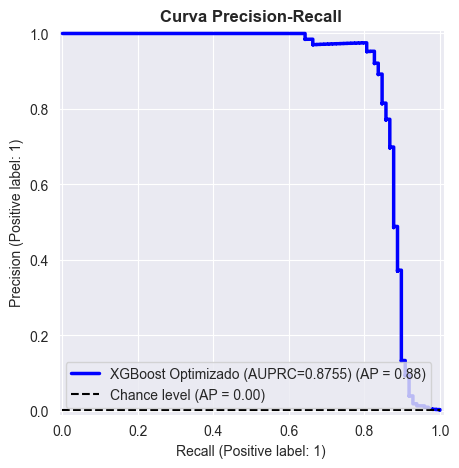

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_estimator(
    xgb_best,
    X_test,
    y_test,
    ax=ax,
    name=f'XGBoost Optimizado (AUPRC={auprc_opt:.4f})',
    color='blue',
    linewidth=2.5,
    plot_chance_level=True
)

ax.set_title('Curva Precision-Recall', fontsize=12, fontweight='bold')
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig('xgb_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()


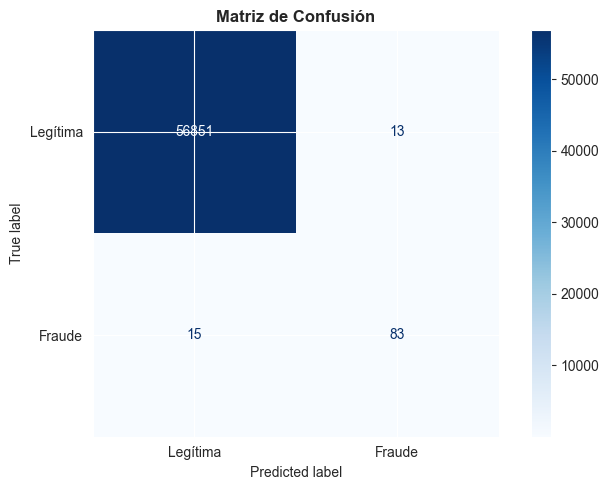

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_estimator(
    xgb_best,
    X_test,
    y_test,
    display_labels=['Legítima', 'Fraude'],
    cmap='Blues',
    ax=ax,
    values_format='d'  # evita notación científica
)

ax.set_title('Matriz de Confusión', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('xgb_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
import os

print("=== EXPORTACIÓN DEL MODELO PARA PRODUCCIÓN ===")

# 1. Creamos una carpeta dedicada para el modelo final
os.makedirs('models', exist_ok=True)

# 2. Definimos la ruta y el nombre de nuestro archivo
ruta_modelo = 'models/xgboost_fraude.pkl'

# 3. Guardamos al modelo campeón (xgb_best)
joblib.dump(xgb_best, ruta_modelo)

ruta_escalador = 'models/robust_scaler.pkl'
joblib.dump(scaler, ruta_escalador)

json_route = 'models/xgboost_weights.json'
with open(json_route, 'w') as archivo:
    json.dump(xgboost_weights, archivo, indent=4)
print(f"Modelo guardado")

=== EXPORTACIÓN DEL MODELO PARA PRODUCCIÓN ===
Modelo guardado
